In [3]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df=pd.read_csv("UberDataset.csv")

In [5]:
df.head()

,START_DATE,END_DATE,CATEGORY,START,STOP,MILES,PURPOSE
0,01-01-2016 21:11,01-01-2016 21:17,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain
1,01-02-2016 01:25,01-02-2016 01:37,Business,Fort Pierce,Fort Pierce,5.0,NaN
2,01-02-2016 20:25,01-02-2016 20:38,Business,Fort Pierce,Fort Pierce,4.8,Errand/Supplies
3,01-05-2016 17:31,01-05-2016 17:45,Business,Fort Pierce,Fort Pierce,4.7,Meeting
4,01-06-2016 14:42,01-06-2016 15:49,Business,Fort Pierce,West Palm Beach,63.7,Customer Visit


In [6]:
df.tail()

,START_DATE,END_DATE,CATEGORY,START,STOP,MILES,PURPOSE
1151,12/31/2016 13:24,12/31/2016 13:42,Business,Kar?chi,Unknown Location,3.9,Temporary Site
1152,12/31/2016 15:03,12/31/2016 15:38,Business,Unknown Location,Unknown Location,16.2,Meeting
1153,12/31/2016 21:32,12/31/2016 21:50,Business,Katunayake,Gampaha,6.4,Temporary Site
1154,12/31/2016 22:08,12/31/2016 23:51,Business,Gampaha,Ilukwatta,48.2,Temporary Site
1155,Totals,NaN,NaN,NaN,NaN,12204.7,NaN


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1156 entries, 0 to 1155
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   START_DATE  1156 non-null   object 
 1   END_DATE    1155 non-null   object 
 2   CATEGORY    1155 non-null   object 
 3   START       1155 non-null   object 
 4   STOP        1155 non-null   object 
 5   MILES       1156 non-null   float64
 6   PURPOSE     653 non-null    object 
dtypes: float64(1), object(6)
memory usage: 63.3+ KB


In [8]:
df.describe()

,MILES
count,1156.000000
mean,21.115398
std,359.299007
min,0.500000
25%,2.900000
50%,6.000000
75%,10.400000
max,12204.700000


In [9]:
df.describe(include='object')

,START_DATE,END_DATE,CATEGORY,START,STOP,PURPOSE
count,1156,1155,1155,1155,1155,653
unique,1155,1154,2,177,188,10
top,6/28/2016 23:34,6/28/2016 23:59,Business,Cary,Cary,Meeting
freq,2,2,1078,201,203,187


In [10]:
df['END_DATE'] = pd.to_datetime(df['END_DATE'], format='mixed',errors='coerce')

In [11]:
df['START_DATE'] = pd.to_datetime(df['START_DATE'], format='mixed', errors='coerce')

In [13]:
df.isna().sum()

START_DATE      1
END_DATE        1
CATEGORY        1
START           1
STOP            1
MILES           0
PURPOSE       503
dtype: int64

In [14]:
df=df.dropna()

In [15]:
df.isna().sum()

START_DATE    0
END_DATE      0
CATEGORY      0
START         0
STOP          0
MILES         0
PURPOSE       0
dtype: int64

In [16]:
df['hour']=df['START_DATE'].dt.hour

In [17]:
df['day']=df['START_DATE'].dt.day

In [18]:
df['weekday']=df['START_DATE'].dt.day_name()

In [19]:
df['month']=df['START_DATE'].dt.month

In [21]:
dict={1:'jan',2:'feb',3:'mar',4:'apr',5:'may',6:'jun',7:'july',8:'aug',9:'sep',10:'oct',11:'nov',12:'dec'}

In [22]:
df['month']=df['month'].map(dict)

In [24]:
df.columns

Index(['START_DATE', 'END_DATE', 'CATEGORY', 'START', 'STOP', 'MILES',
       'PURPOSE', 'hour', 'day', 'weekday', 'month'],
      dtype='object')

In [26]:
df['CATEGORY'].value_counts()

CATEGORY
Business    647
Personal      6
Name: count, dtype: int64

In [27]:
df.shape

(653, 11)

In [28]:
df.columns[0]

'START_DATE'

In [29]:
df.dtypes

START_DATE    datetime64[ns]
END_DATE      datetime64[ns]
CATEGORY              object
START                 object
STOP                  object
MILES                float64
PURPOSE               object
hour                   int32
day                    int32
weekday               object
month                 object
dtype: object

In [30]:
numeric=df.select_dtypes(include=[np.number])

In [34]:
df[df.duplicated]

,START_DATE,END_DATE,CATEGORY,START,STOP,MILES,PURPOSE,hour,day,weekday,month
492,2016-06-28 23:34:00,2016-06-28 23:59:00,Business,Durham,Cary,9.9,Meeting,23,28,Tuesday,jun


In [35]:
df.drop_duplicates(inplace=True)

In [36]:
df[df.duplicated]

,START_DATE,END_DATE,CATEGORY,START,STOP,MILES,PURPOSE,hour,day,weekday,month


In [38]:
from datetime import datetime

In [39]:
df['day-night']=pd.cut(df['hour'],bins=[0,10,15,19,24],labels=["Morning","Afternoon","Evening","Night"])

# Data Visualization

# Histogram

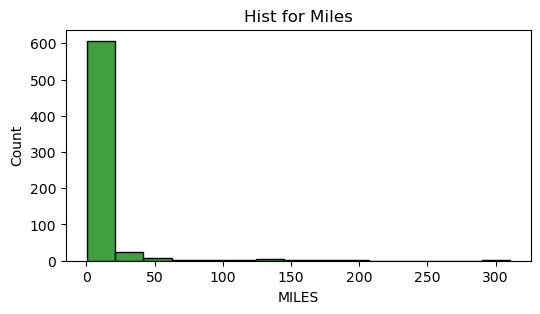

In [41]:
plt.figure(figsize=(6,3))
sns.histplot(df['MILES'],bins=15,color="green",edgecolor="black")
plt.title("Hist for Miles")
plt.show()

In [44]:
import warnings
warnings.filterwarnings("ignore")

# Count Plot

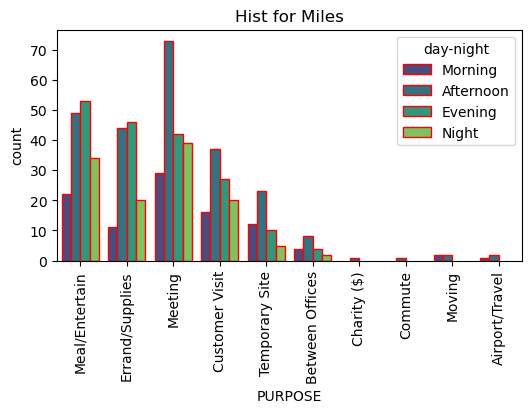

In [45]:
plt.figure(figsize=(6,3))
sns.countplot(data=df,x='PURPOSE',palette="viridis",hue='day-night',edgecolor="red")
plt.title("Hist for Miles")
plt.xticks(rotation=90)
plt.show()

# Heatmap

In [48]:
heat=df.groupby(['PURPOSE','day-night']).size().unstack()

<Axes: xlabel='day-night', ylabel='PURPOSE'>

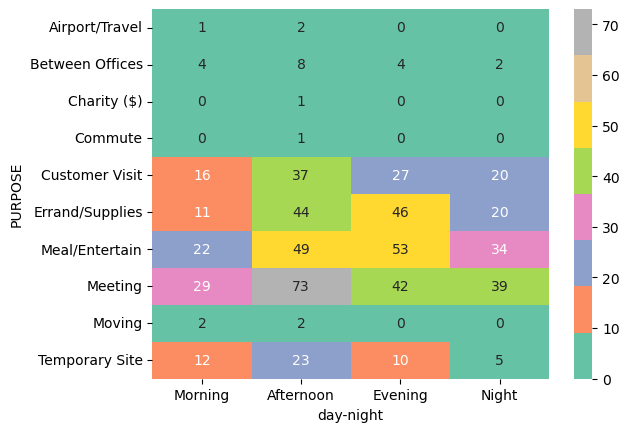

In [49]:
sns.heatmap(heat,annot=True,cmap='Set2',fmt='d')

In [50]:
heat=df.groupby(['PURPOSE','CATEGORY','day-night']).size().unstack(-1)

In [52]:
tot=heat.sum().sum()

In [53]:
tot

np.int64(639)

# Pie chart

In [57]:
df['CATEGORY'].unique()


array(['Business', 'Personal'], dtype=object)

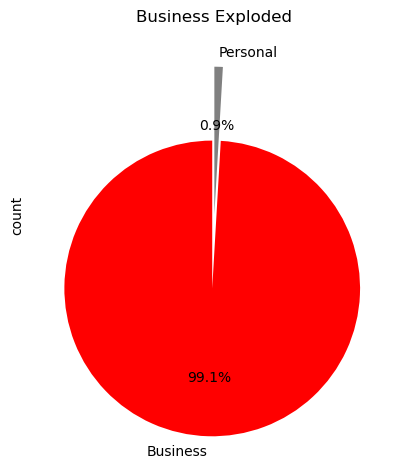

In [58]:
counts = df['CATEGORY'].value_counts().reindex(['Business','Personal'])

plt.figure()

counts.plot.pie(
    labels=counts.index,
    autopct="%1.1f%%",
    explode=[0.5, 0],
    colors=['red','gray'],
    startangle=90
)

plt.title("Business Exploded")
plt.show()


# custom pct

# Box plot

<Axes: xlabel='day-night', ylabel='MILES'>

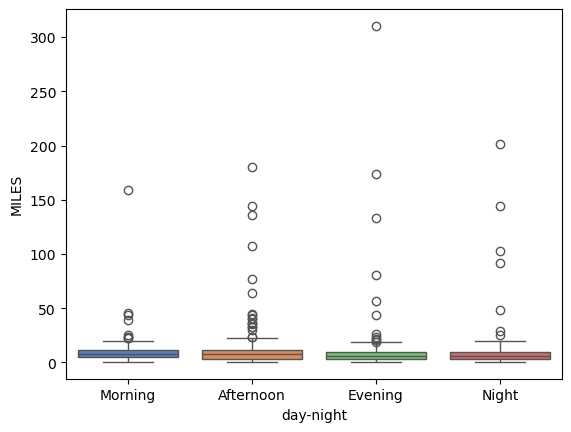

In [63]:
sns.boxplot(data=df,x='day-night',y='MILES',palette='muted')

<Axes: xlabel='day-night', ylabel='MILES'>

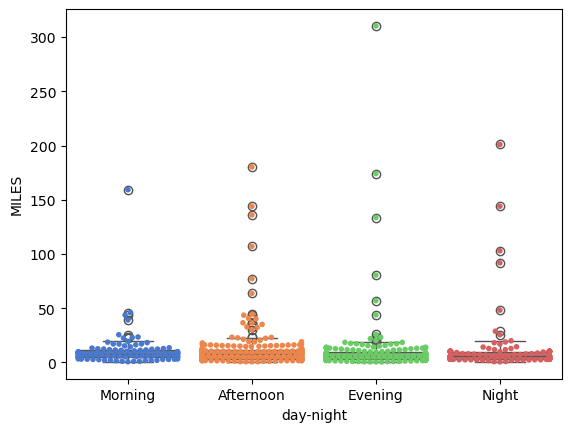

In [64]:
sns.boxplot(data=df,x='day-night',y='MILES',palette='muted')
sns.swarmplot(data=df,x='day-night',y='MILES',palette='muted',size=4)

# Violin plot

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9],
 [Text(0, 0, 'Meal/Entertain'),
  Text(1, 0, 'Errand/Supplies'),
  Text(2, 0, 'Meeting'),
  Text(3, 0, 'Customer Visit'),
  Text(4, 0, 'Temporary Site'),
  Text(5, 0, 'Between Offices'),
  Text(6, 0, 'Charity ($)'),
  Text(7, 0, 'Commute'),
  Text(8, 0, 'Moving'),
  Text(9, 0, 'Airport/Travel')])

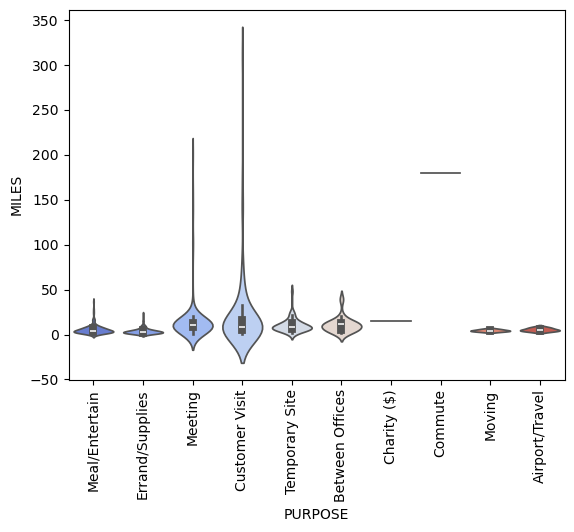

In [67]:
sns.violinplot(data=df,x='PURPOSE',y='MILES',palette="coolwarm")
plt.xticks(rotation=90)

# Bar plot

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9],
 [Text(0, 0, 'Meal/Entertain'),
  Text(1, 0, 'Errand/Supplies'),
  Text(2, 0, 'Meeting'),
  Text(3, 0, 'Customer Visit'),
  Text(4, 0, 'Temporary Site'),
  Text(5, 0, 'Between Offices'),
  Text(6, 0, 'Charity ($)'),
  Text(7, 0, 'Commute'),
  Text(8, 0, 'Moving'),
  Text(9, 0, 'Airport/Travel')])

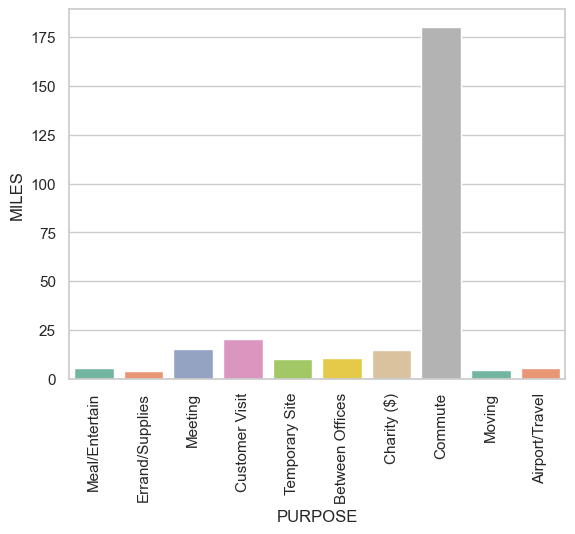

In [71]:
sns.barplot(data=df,x='PURPOSE',y='MILES',palette="Set2",estimator=np.mean,ci=None)
plt.xticks(rotation=90)

# scatte plot

<Axes: xlabel='MILES', ylabel='hour'>

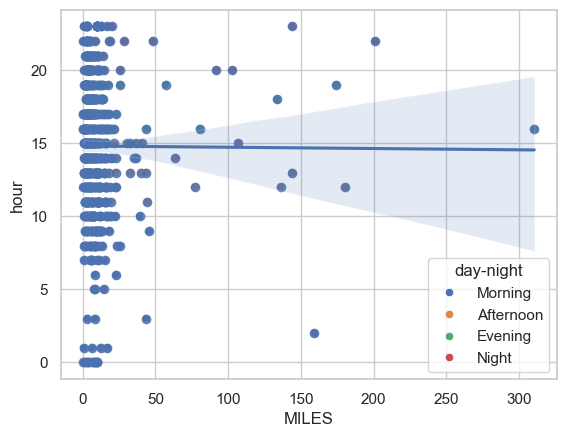

In [75]:
sns.scatterplot(data=df,x='MILES',y='hour',hue='day-night')
sns.regplot(data=df,x='MILES',y='hour')

# Line plot

In [78]:
df['minutes']=df['START_DATE'].dt.minute

<Axes: xlabel='minutes', ylabel='MILES'>

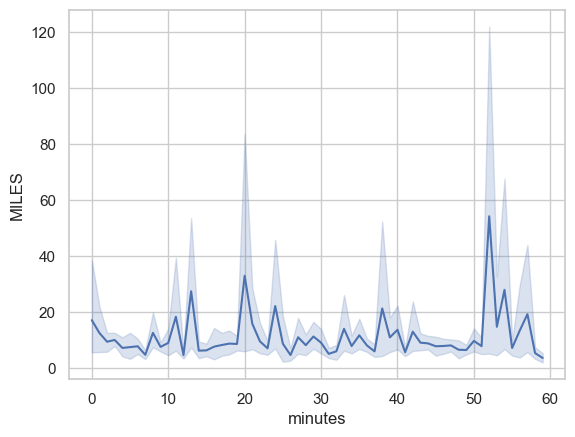

In [81]:
sns.lineplot(data=df,x=df['minutes'],y='MILES')

# New column called trip_duration

In [87]:
df['trip_duration']=(df['END_DATE']-df['START_DATE']).dt.total_seconds()/60

# Average trip_duration for each PURPOSE of ride.

In [89]:
df.groupby('PURPOSE')['trip_duration'].mean()

PURPOSE
Airport/Travel      26.000000
Between Offices     25.500000
Charity ($)         27.000000
Commute            185.000000
Customer Visit      33.415842
Errand/Supplies     12.976562
Meal/Entertain      16.125000
Meeting             29.763441
Moving              15.000000
Temporary Site      25.860000
Name: trip_duration, dtype: float64

# Find which PURPOSE has the highest total MILES traveled.

In [92]:
df.groupby('PURPOSE')['MILES'].sum().sort_values(ascending=False).head(1)

PURPOSE
Meeting    2841.4
Name: MILES, dtype: float64

# Find the top 5 START locations where rides begin most often.

In [93]:
df["START"].value_counts().sort_values(ascending=False).head()

START
Cary                161
Unknown Location     55
Morrisville          54
Whitebridge          36
Durham               29
Name: count, dtype: int64

# Find the top 5 STOP locations where rides end most often.

In [95]:
df["STOP"].value_counts().sort_values(ascending=False).head()

STOP
Cary                154
Morrisville          60
Unknown Location     56
Whitebridge          37
Durham               30
Name: count, dtype: int64

# Find the average MILES traveled for each CATEGORY (Business vs Personal).

In [96]:
df.groupby('CATEGORY')['MILES'].mean()

CATEGORY
Business    10.971827
Personal    35.583333
Name: MILES, dtype: float64

# Find which month has the highest number of rides.

In [97]:
df['month'].value_counts().sort_values(ascending=False).head(1)

month
dec    134
Name: count, dtype: int64

# Find which weekday has the highest total MILES traveled.

In [106]:
df.groupby('weekday')["MILES"].sum().sort_values(ascending=False).head(1).index

Index(['Friday'], dtype='object', name='weekday')

# Find the peak hour — which hour has the highest number of rides

In [111]:
df['hour'].value_counts().idxmax()

np.int32(13)